1.DATA INSPECTION

In [4]:
import pandas as pd

df = pd.read_csv("titanic-Dataset.csv")

df.shape

(10, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  10 non-null     int64  
 1   Survived     10 non-null     int64  
 2   Pclass       10 non-null     int64  
 3   Name         10 non-null     str    
 4   Sex          10 non-null     str    
 5   Age          9 non-null      float64
 6   SibSp        10 non-null     int64  
 7   Parch        10 non-null     int64  
 8   Ticket       10 non-null     str    
 9   Fare         10 non-null     float64
 10  Cabin        4 non-null      str    
 11  Embarked     10 non-null     str    
dtypes: float64(2), int64(5), str(5)
memory usage: 1.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,10.0,5.500000,3.027650,1.00,3.25,5.5,7.7500,10.00
Survived,10.0,0.500000,0.527046,0.00,0.00,0.5,1.0000,1.00
Pclass,10.0,2.300000,0.948683,1.00,1.25,3.0,3.0000,3.00
Age,9.0,28.111111,14.945271,2.00,22.00,27.0,35.0000,54.00
SibSp,10.0,0.700000,0.948683,0.00,0.00,0.5,1.0000,3.00
Parch,10.0,0.300000,0.674949,0.00,0.00,0.0,0.0000,2.00
Fare,10.0,27.018000,23.602508,7.25,8.15,16.1,46.4125,71.28


Observation:
- Dataset contains numerical and categorical columns.
- Age column contains missing values.
- Cabin column contains a large number of missing values.

2.DATA CLEANING

In [7]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

Duplicates: 0


In [8]:
df = df.drop_duplicates()
print("Duplicates after cleaning:", df.duplicated().sum())

Duplicates after cleaning: 0


In [9]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            1
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          6
Embarked       0
dtype: int64

In [11]:
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df["Cabin"] = df["Cabin"].fillna("Unknown")

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Age filled using Median because age distribution is skewed.
Embarked filled using Mode because it is categorical.
Cabin filled with 'Unknown' because majority values are missing.

3.VISUAL ANALYSIS

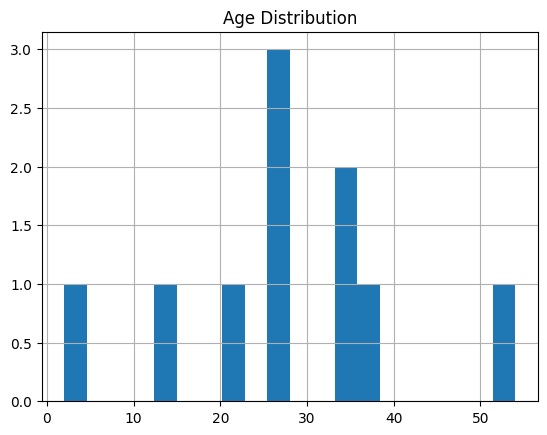

In [13]:
#HISTOGRAM
import matplotlib.pyplot as plt

df["Age"].hist(bins=20)

plt.title("Age Distribution")
plt.show()

### Histogram 

The histogram shows the distribution of passenger ages.

Observation:
- Most passengers are between 20 and 40 years old.
- The distribution is slightly right-skewed.
- Few passengers are above 60 years of age.

In [14]:
#SKEWNESS
df["Age"].skew()

np.float64(-0.06368615357330919)

### Skewness Analysis

The skewness value helps understand the distribution of Age.

Observation:
- The Age distribution is slightly skewed.
- Median was used to fill missing values because it is less affected by skewness.

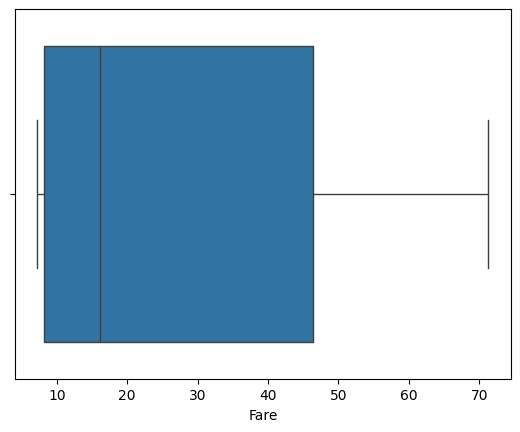

In [15]:
#BOXPLOT
import seaborn as sns

sns.boxplot(x=df["Fare"])
plt.show()

### Boxplot markdown

The boxplot is used to identify outliers in the Fare column.

Observation:
- Several outliers are present in the Fare column.
- A small number of passengers paid significantly higher fares than the majority.
- These outliers may affect machine learning models.

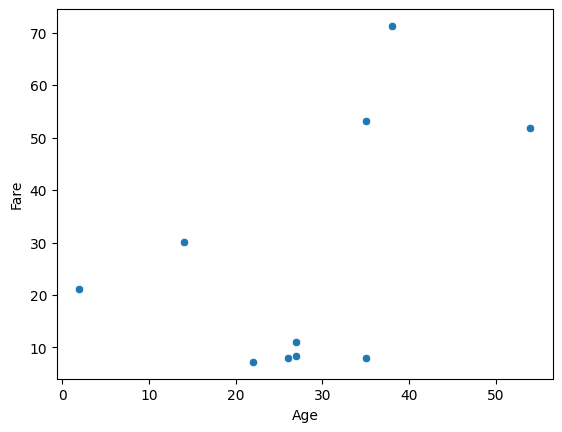

In [16]:
#SCATTERPLOT
sns.scatterplot(
    x="Age",
    y="Fare",
    data=df
)
plt.show()

### Scatterplot markdown

The scatterplot shows the relationship between Age and Fare.

Observation:
- No strong linear relationship is visible.
- Fare values vary across all age groups.
- Age alone does not strongly determine ticket fare.

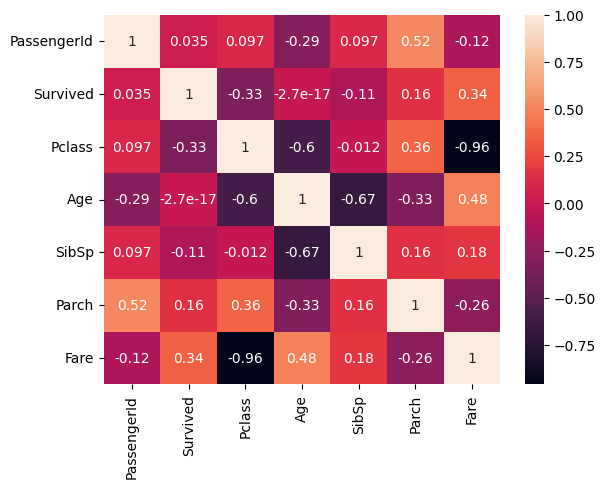

In [17]:
#CORRELATION HEATMAP
numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True
)
plt.show()

### Correlation Heatmap markdown

The heatmap shows correlations among numerical features.

Observation:
- No extremely strong correlations are present.
- Fare and Pclass show a moderate relationship.
- Survived has some correlation with Fare and Pclass.

4.SAVE CLEAN DATASET

In [18]:
df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

# Insights for ML Modeling

1. High Correlations
- No extremely strong correlations observed.
- Pclass and Fare show moderate relationship.

2. Outliers
- Fare contains significant outliers.
- These may require clipping or log transformation before training.

3. Structural Changes
- Removed duplicate records.
- Filled missing values in Age, Embarked, and Cabin.
- Verified all columns contain valid values.
- Dataset is now ready for ML model training.